# Person Segmentation with U-Net

DATASET: [Person Segmentation Dataset](https://stylegan-human.github.io/data.html)

Train a U-Net to predict person segmentation masks.
- **Input**: original photo with background (`no_segment/`)
- **Output**: binary mask derived from the extracted person (`segments/`)

In [14]:
import os
import random
import numpy as np
from PIL import Image, ImageFilter
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from tqdm.notebook import tqdm

# Utiliser le GPU 1 (le GPU 0 est occupe)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda:0


## 1. Data Exploration

Original photos (no_segment/): 40000
Segmented persons (segments/): 40000


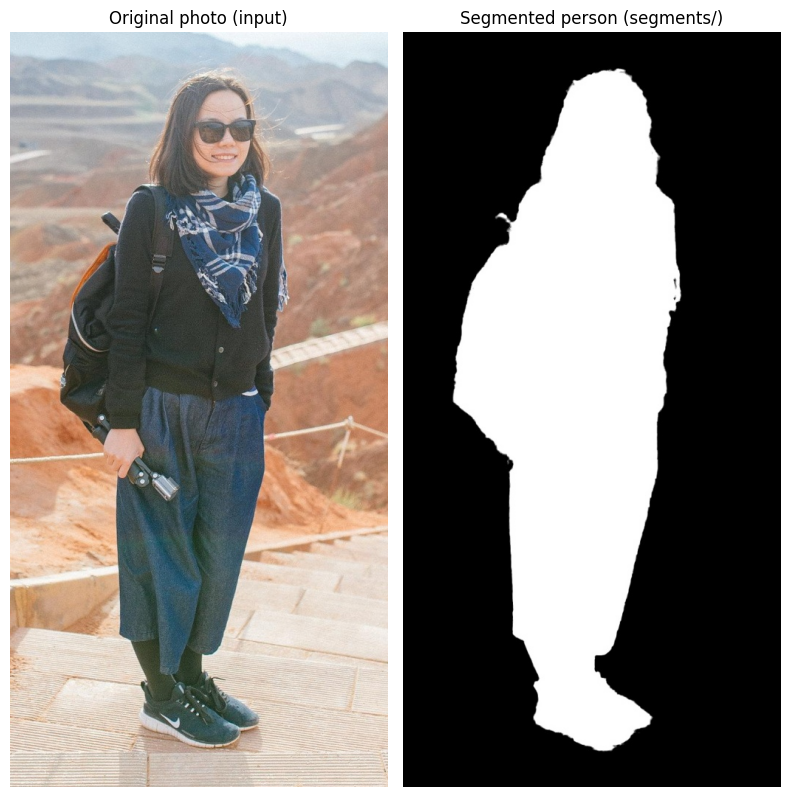

In [15]:
NO_SEG_DIR = './SHHQ-1.0/no_segment'    # Original photos with background (input)
SEGMENTS_DIR = './SHHQ-1.0/segments'     # Extracted person on black background (used to derive masks)

noseg_files = sorted(os.listdir(NO_SEG_DIR))
seg_files = sorted(os.listdir(SEGMENTS_DIR))
print(f'Original photos (no_segment/): {len(noseg_files)}')
print(f'Segmented persons (segments/): {len(seg_files)}')

# Show an example pair
fig, axes = plt.subplots(1, 2, figsize=(8, 8))
orig = Image.open(os.path.join(NO_SEG_DIR, noseg_files[0]))
segmented = Image.open(os.path.join(SEGMENTS_DIR, seg_files[0]))
axes[0].imshow(orig); axes[0].set_title('Original photo (input)')
axes[1].imshow(segmented); axes[1].set_title('Segmented person (segments/)')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

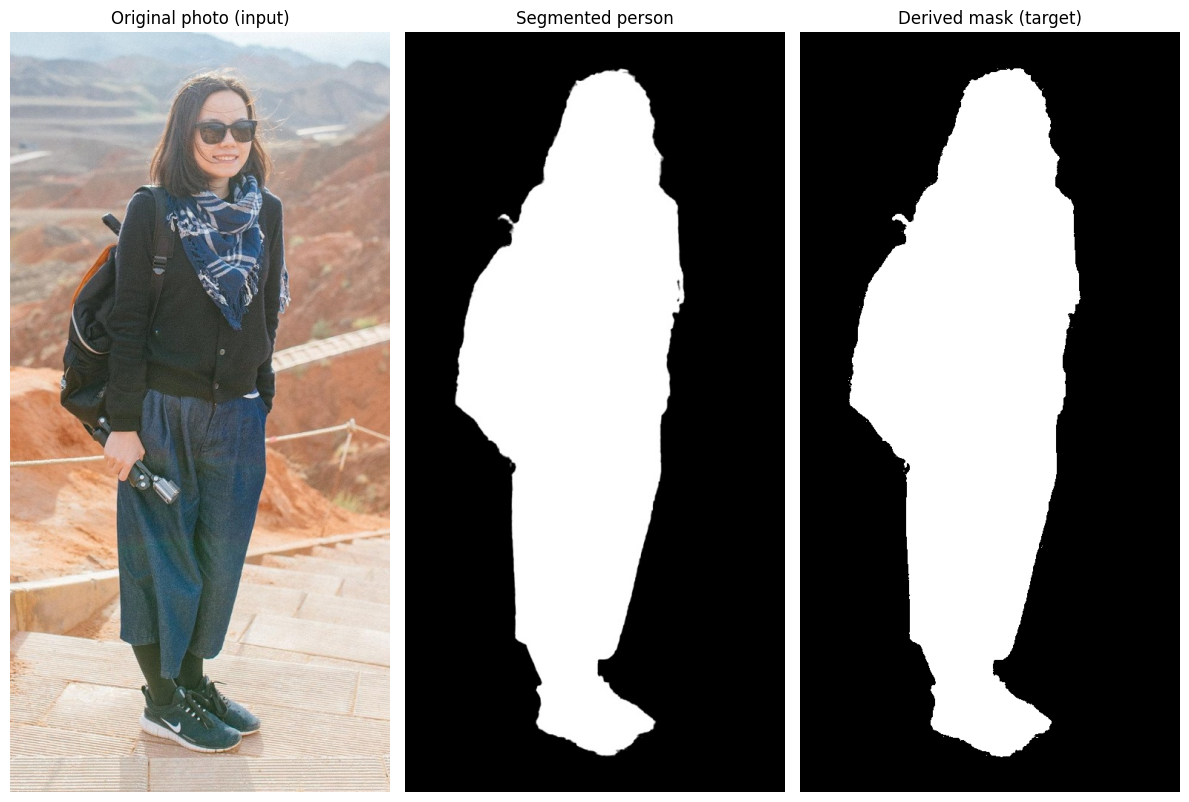

In [16]:
# Derive binary mask from segmented image (non-black pixels = person)
segmented_np = np.array(segmented)
mask = (segmented_np.sum(axis=2) > 15).astype(np.uint8) * 255  # threshold to handle JPEG artifacts

fig, axes = plt.subplots(1, 3, figsize=(12, 8))
axes[0].imshow(orig); axes[0].set_title('Original photo (input)')
axes[1].imshow(segmented); axes[1].set_title('Segmented person')
axes[2].imshow(mask, cmap='gray'); axes[2].set_title('Derived mask (target)')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

## 2. Dataset with Augmentation

In [17]:
class SegmentationDataset(Dataset):
    """Paired dataset: original photo -> binary mask derived from segmented person."""
    
    def __init__(self, noseg_dir, seg_dir, img_size=512, is_train=True):
        self.noseg_dir = noseg_dir  # original photos (input)
        self.seg_dir = seg_dir      # segmented persons on black bg (to derive mask)
        self.img_size = img_size
        self.is_train = is_train
        
        self.noseg_files = sorted([f for f in os.listdir(noseg_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        self.seg_files = sorted([f for f in os.listdir(seg_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        
        # Build mapping: same filename in both folders
        seg_set = set(self.seg_files)
        self.pairs = [(f, f) for f in self.noseg_files if f in seg_set]
        
        print(f'Found {len(self.pairs)} paired samples')
    
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        noseg_file, seg_file = self.pairs[idx]
        
        # Load original photo (input)
        img = Image.open(os.path.join(self.noseg_dir, noseg_file)).convert('RGB')
        
        # Load segmented person and derive mask
        segmented = Image.open(os.path.join(self.seg_dir, seg_file)).convert('RGB')
        seg_np = np.array(segmented).astype(np.float32)
        mask = (seg_np.sum(axis=2) > 15).astype(np.float32)
        mask = Image.fromarray((mask * 255).astype(np.uint8), mode='L')
        
        # Resize
        img = img.resize((self.img_size, self.img_size), Image.BILINEAR)
        mask = mask.resize((self.img_size, self.img_size), Image.NEAREST)
        
        # Augmentation (same spatial transforms on both)
        if self.is_train:
            if random.random() > 0.5:
                img = TF.hflip(img)
                mask = TF.hflip(mask)
            
            angle = random.uniform(-10, 10)
            img = TF.rotate(img, angle, fill=0)
            mask = TF.rotate(mask, angle, fill=0)
            
            # Color jitter (image only, not mask)
            img = TF.adjust_brightness(img, random.uniform(0.85, 1.15))
            img = TF.adjust_contrast(img, random.uniform(0.85, 1.15))
            img = TF.adjust_saturation(img, random.uniform(0.85, 1.15))
            img = TF.adjust_hue(img, random.uniform(-0.05, 0.05))
        
        img_tensor = TF.to_tensor(img)   # [3, H, W] in [0, 1]
        mask_tensor = TF.to_tensor(mask)  # [1, H, W] in [0, 1]
        
        return img_tensor, mask_tensor

Found 40000 paired samples


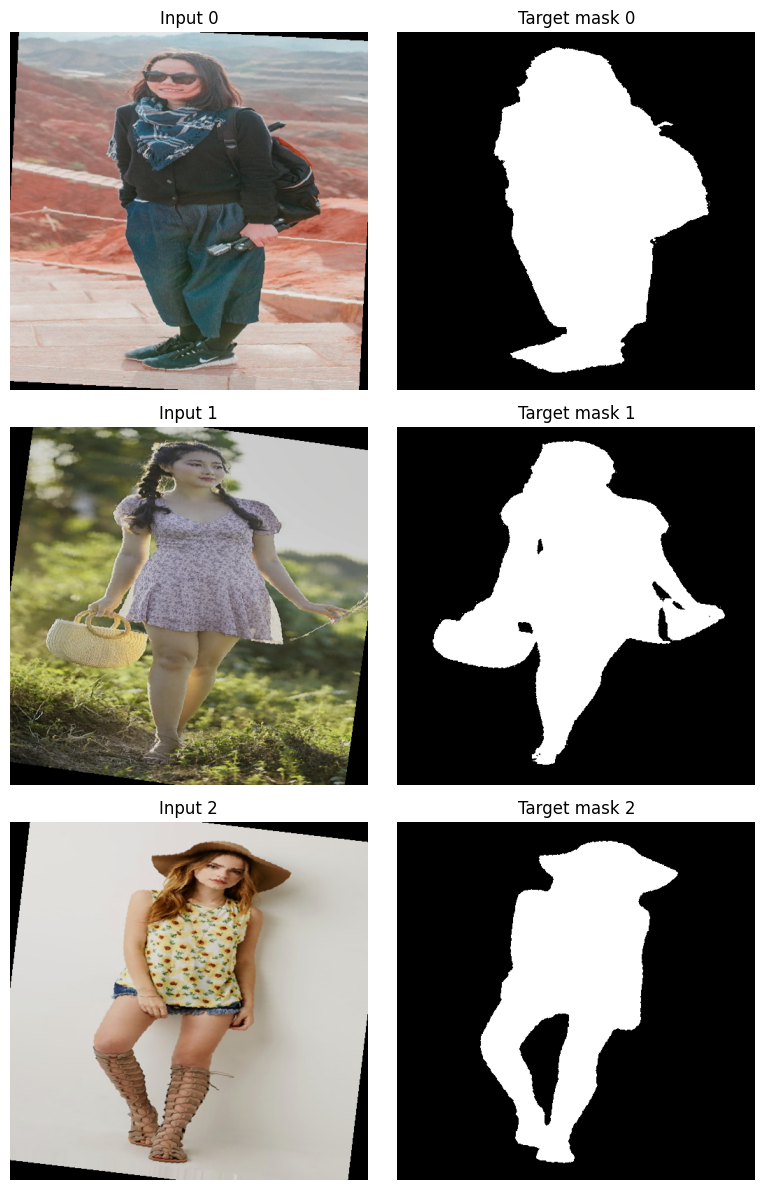

In [18]:
# Visualize dataset samples
dataset = SegmentationDataset(NO_SEG_DIR, SEGMENTS_DIR, img_size=512, is_train=True)

fig, axes = plt.subplots(min(3, len(dataset)), 2, figsize=(8, 12))
if len(dataset) == 1:
    axes = axes[None, :]
for i in range(min(3, len(dataset))):
    img, mask = dataset[i]
    axes[i, 0].imshow(img.permute(1, 2, 0).numpy())
    axes[i, 0].set_title(f'Input {i}')
    axes[i, 1].imshow(mask.squeeze().numpy(), cmap='gray')
    axes[i, 1].set_title(f'Target mask {i}')
for ax in axes.flat: ax.axis('off')
plt.tight_layout()
plt.show()

## 3. U-Net Model

In [19]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    
    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[64, 128, 256, 512]):
        super().__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(2, 2)
        
        # Encoder
        for f in features:
            self.downs.append(ConvBlock(in_channels, f))
            in_channels = f
        
        # Bottleneck
        self.bottleneck = ConvBlock(features[-1], features[-1] * 2)
        
        # Decoder
        for f in reversed(features):
            self.ups.append(nn.ConvTranspose2d(f * 2, f, kernel_size=2, stride=2))
            self.ups.append(ConvBlock(f * 2, f))
        
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)
    
    def forward(self, x):
        skip_connections = []
        
        # Encoder
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)
        
        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]
        
        # Decoder
        for i in range(0, len(self.ups), 2):
            x = self.ups[i](x)  # upsample
            skip = skip_connections[i // 2]
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=True)
            x = torch.cat([skip, x], dim=1)
            x = self.ups[i + 1](x)  # conv block
        
        return torch.sigmoid(self.final_conv(x))


# Test the model
model = UNet().to(device)
x = torch.randn(1, 3, 512, 512).to(device)
with torch.no_grad():
    y = model(x)
print(f'Input: {x.shape} -> Output: {y.shape}')
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Input: torch.Size([1, 3, 512, 512]) -> Output: torch.Size([1, 1, 512, 512])
Parameters: 31,043,521


## 4. Loss Function & Training Setup

In [20]:
class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5):
        super().__init__()
        self.bce_weight = bce_weight
        self.bce = nn.BCELoss()
    
    def forward(self, pred, target):
        bce_loss = self.bce(pred, target)
        
        # Dice loss
        smooth = 1e-5
        pred_flat = pred.view(-1)
        target_flat = target.view(-1)
        intersection = (pred_flat * target_flat).sum()
        dice = (2.0 * intersection + smooth) / (pred_flat.sum() + target_flat.sum() + smooth)
        dice_loss = 1 - dice
        
        return self.bce_weight * bce_loss + (1 - self.bce_weight) * dice_loss


from datetime import datetime

# Hyperparameters
IMG_SIZE = 512
BATCH_SIZE = 16
NUM_EPOCHS = 50
LR = 1e-4
MODEL_NAME = 'unet_segmentation'

# Checkpoint & log directories
CHECKPOINT_DIR = f'checkpoint/{MODEL_NAME}'
LOG_FILE = f'log/{MODEL_NAME}/training_log.txt'

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(os.path.dirname(LOG_FILE), exist_ok=True)

# Dataset
train_dataset = SegmentationDataset(NO_SEG_DIR, SEGMENTS_DIR, img_size=IMG_SIZE, is_train=True)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)

# Model, loss, optimizer
model = UNet(in_channels=3, out_channels=1).to(device)
criterion = BCEDiceLoss(bce_weight=0.5)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

# Resume from checkpoint if available
EPOCH_START = 0
checkpoint_files = sorted(
    [f for f in os.listdir(CHECKPOINT_DIR) if f.startswith('epoch-') and f.endswith('.pth')],
    key=lambda x: int(x.split('-')[1].split('.pth')[0])
)
if checkpoint_files:
    latest_ckpt = os.path.join(CHECKPOINT_DIR, checkpoint_files[-1])
    checkpoint = torch.load(latest_ckpt, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    EPOCH_START = checkpoint['epoch'] + 1
    print(f'Resumed from checkpoint: {latest_ckpt} (starting at epoch {EPOCH_START})')
else:
    print('No checkpoint found, starting from scratch.')

print(f'Training samples per epoch: {len(train_dataset)}')
print(f'Batches per epoch: {len(train_loader)}')

Found 40000 paired samples
Resumed from checkpoint: checkpoint/unet_segmentation/epoch-39.pth (starting at epoch 40)
Training samples per epoch: 40000
Batches per epoch: 2500


## 5. Training

In [ ]:
# Training loop
history = {'loss': [], 'dice': []}
early_stop_patience = 5
early_stop_min_delta = 0.import numpy as np
from PIL import Image, ImageFilter
import matplotlib.pyplot as plt

001
stagnant_epochs = 0

for epoch in range(EPOCH_START, NUM_EPOCHS):
    model.train()
    epoch_loss = 0
    epoch_dice = 0
    n_batches = 0
    
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS}', leave=True)
    for images, masks in pbar:
        images = images.to(device)
        masks = masks.to(device)
        
        preds = model(images)
        loss = criterion(preds, masks)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        with torch.no_grad():
            pred_bin = (preds > 0.5).float()
            intersection = (pred_bin * masks).sum()
            dice = (2 * intersection) / (pred_bin.sum() + masks.sum() + 1e-5)
        
        epoch_loss += loss.item()
        epoch_dice += dice.item()
        n_batches += 1
        
        pbar.set_postfix(loss=f'{epoch_loss/n_batches:.4f}', dice=f'{epoch_dice/n_batches:.4f}')
    
    avg_loss = epoch_loss / n_batches
    avg_dice = epoch_dice / n_batches
    history['loss'].append(avg_loss)
    history['dice'].append(avg_dice)
    scheduler.step(avg_loss)
    
    current_lr = optimizer.param_groups[0]["lr"]
    print(f'  -> Loss: {avg_loss:.4f} Dice: {avg_dice:.4f} LR: {current_lr:.6f}')
    
    # Save checkpoint
    ckpt_path = os.path.join(CHECKPOINT_DIR, f'epoch-{epoch}.pth')
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': avg_loss,
        'dice': avg_dice,
        'history': history,
    }, ckpt_path)
    
    # Update log file
    now = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    log_line = f'[{now}] Epoch {epoch+1}/{NUM_EPOCHS} - Loss: {avg_loss:.4f} - Dice: {avg_dice:.4f} - LR: {current_lr:.6f} - Checkpoint: {ckpt_path}\n'
    with open(LOG_FILE, 'a') as f:
        f.write(log_line)
    print(f'  -> Checkpoint saved: {ckpt_path}')
    
    # Early stopping
    if len(history['loss']) >= 2:
        delta = history['loss'][-2] - history['loss'][-1]
        if delta < early_stop_min_delta:
            stagnant_epochs += 1
            if stagnant_epochs >= early_stop_patience:
                print(f'Early stopping: loss stagnante depuis {early_stop_patience} epochs')
                break
        else:
            stagnant_epochs = 0

Epoch 35/50:   0%|          | 0/2500 [00:00<?, ?it/s]

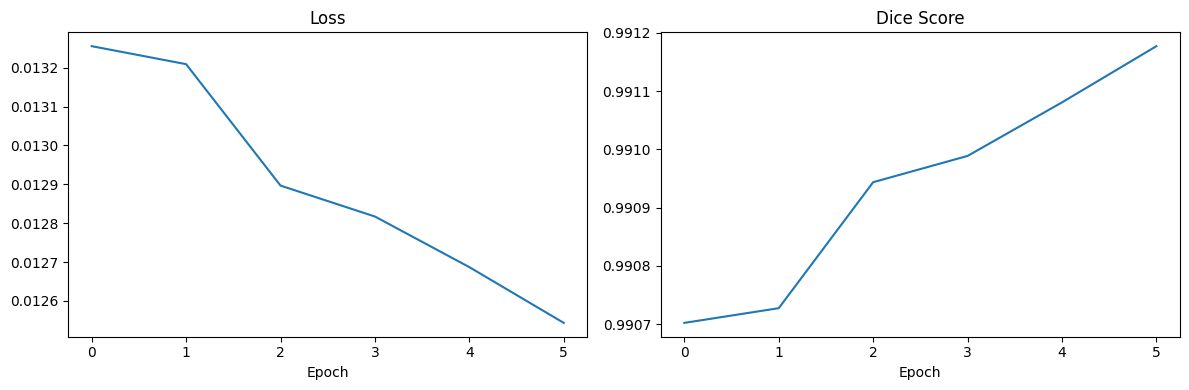

In [21]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history['loss']); ax1.set_title('Loss'); ax1.set_xlabel('Epoch')
ax2.plot(history['dice']); ax2.set_title('Dice Score'); ax2.set_xlabel('Epoch')
plt.tight_layout()
plt.show()

## 6. Evaluation

Found 40000 paired samples


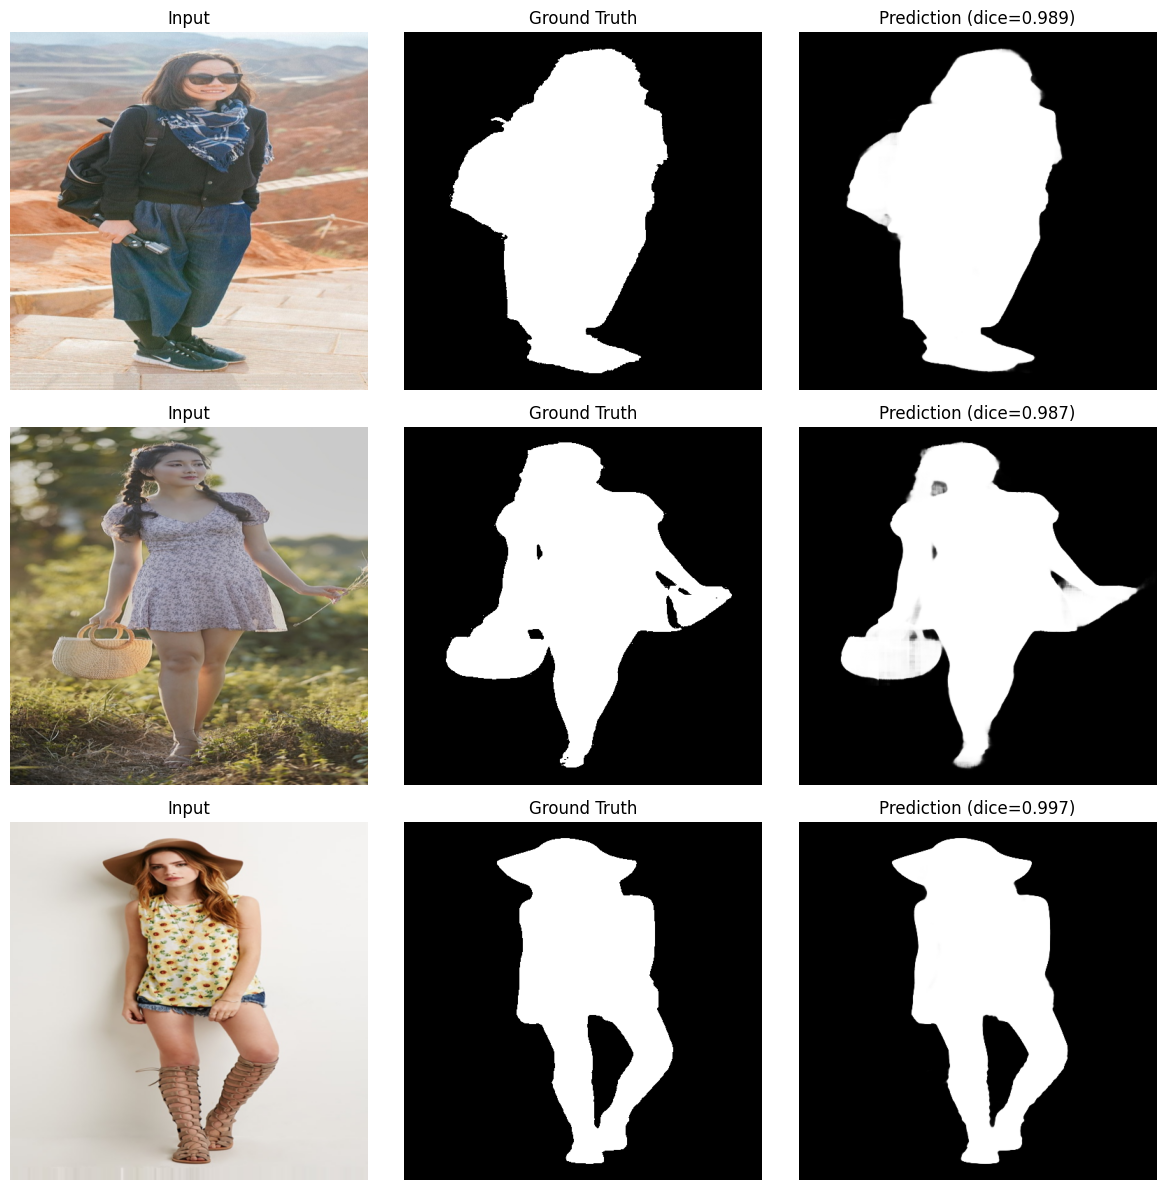

In [22]:
# Visualize predictions
model.eval()
eval_dataset = SegmentationDataset(NO_SEG_DIR, SEGMENTS_DIR, img_size=IMG_SIZE, is_train=False)

fig, axes = plt.subplots(min(3, len(eval_dataset)), 3, figsize=(12, 12))
if len(eval_dataset) == 1:
    axes = axes[None, :]
for i in range(min(3, len(eval_dataset))):
    img, mask = eval_dataset[i]
    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(device)).cpu().squeeze()
    
    axes[i, 0].imshow(img.permute(1, 2, 0).numpy())
    axes[i, 0].set_title('Input')
    axes[i, 1].imshow(mask.squeeze().numpy(), cmap='gray')
    axes[i, 1].set_title('Ground Truth')
    axes[i, 2].imshow(pred.numpy(), cmap='gray')
    pred_bin = (pred > 0.5).float()
    dice = (2 * (pred_bin * mask.squeeze()).sum() / (pred_bin.sum() + mask.squeeze().sum() + 1e-5)).item()
    axes[i, 2].set_title(f'Prediction (dice={dice:.3f})')

for ax in axes.flat: ax.axis('off')
plt.tight_layout()
plt.show()

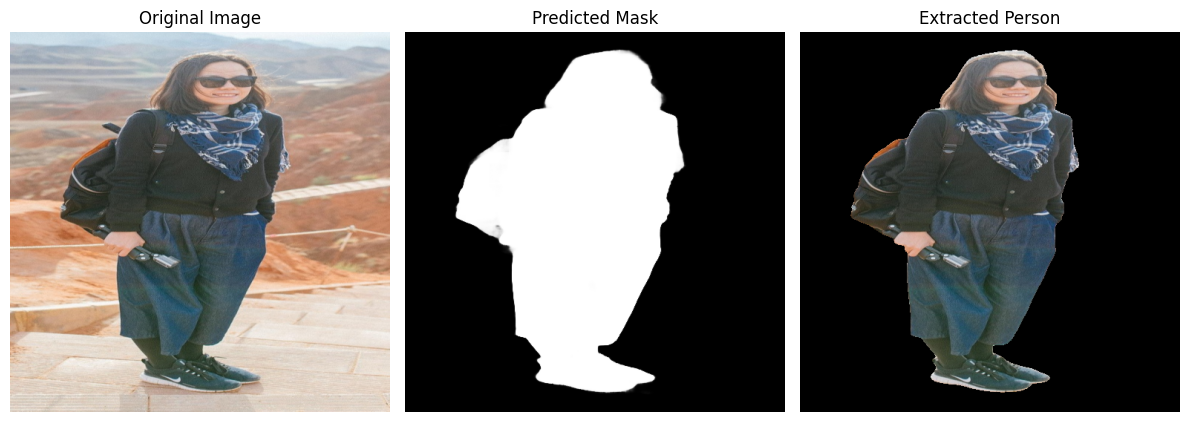

In [23]:
# Apply predicted mask to extract the person
model.eval()

img, mask_gt = eval_dataset[0]
with torch.no_grad():
    pred = model(img.unsqueeze(0).to(device)).cpu().squeeze().numpy()

img_np = img.permute(1, 2, 0).numpy()
extracted = img_np * (pred > 0.5)[..., None]

fig, axes = plt.subplots(1, 3, figsize=(12, 6))
axes[0].imshow(img_np); axes[0].set_title('Original Image')
axes[1].imshow(pred, cmap='gray'); axes[1].set_title('Predicted Mask')
axes[2].imshow(extracted); axes[2].set_title('Extracted Person')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

## 7. Save Model

In [ ]:
# Save final model (also available as individual epoch checkpoints in checkpoint/<MODEL_NAME>/)
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history,
}, 'unet_segmentation.pth')
print('Model saved to unet_segmentation.pth')
print(f'Checkpoints available in: {CHECKPOINT_DIR}/')
print(f'Training log: {LOG_FILE}')

## 8. Inference on New Images

In [ ]:
def segment_person(model, image_path, img_size=512):
    """Segment a person from an image and display before/after."""
    model.eval()
    img = Image.open(image_path).convert('RGB')
    img_resized = img.resize((img_size, img_size), Image.BILINEAR)
    img_tensor = TF.to_tensor(img_resized).unsqueeze(0).to(device)
    
    with torch.no_grad():
        pred = model(img_tensor).cpu().squeeze().numpy()
    
    img_np = np.array(img_resized).astype(np.float32) / 255.0
    mask_bin = (pred > 0.5).astype(np.float32)
    extracted = img_np * mask_bin[..., None]
    
    fig, axes = plt.subplots(1, 2, figsize=(8, 6))
    axes[0].imshow(img_np); axes[0].set_title('Avant')
    axes[1].imshow(extracted); axes[1].set_title('Apres')
    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.show()

# Example usage:
# segment_person(model, 'path/to/your/image.jpg')